In [19]:
# IMPORTS
import pandas as pd
import os
import matplotlib.pyplot as plt

In [20]:
path = "../data"

files = os.listdir(path)

all_data = []

for file in files:
    if file.endswith(".csv"):
        df_temp = pd.read_csv(os.path.join(path, file))
        df_temp['source_file'] = file
        all_data.append(df_temp)

df = pd.concat(all_data, ignore_index=True)

print("Raw Data Shape:", df.shape)
print(df.head())


Raw Data Shape: (253, 22)
  Unnamed: 0 Unnamed: 1 Unnamed: 2 Unnamed: 3      Kharif    Unnamed: 5  \
0      Sr.No        NaN      Crops        NaN         NaN           NaN   
1        NaN        NaN        NaN       Area  Production  Productivity   
2          1       Rice        NaN     1417.4      3143.7        2217.9   
3          2      Wheat        NaN        NaN         NaN           NaN   
4          3      Jowar        NaN      530.3       429.7         810.2   

  Unnamed: 6        Rabi    Unnamed: 8 Unnamed: 9  ...  \
0        NaN         NaN           NaN        NaN  ...   
1       Area  Production  Productivity       Area  ...   
2        NaN         NaN           NaN      47.54  ...   
3      834.4      1249.2        1497.1        NaN  ...   
4     1909.2       767.6         402.1        NaN  ...   

  Total (Kharif + RabI + summer)                source_file  \
0                            NaN  maha data 2018 - 2019.csv   
1   Area Production Productivity  maha data 2018

In [21]:
# Remove first 2 rows (extra headers)
df_clean = df.iloc[2:].copy()
df_clean.reset_index(drop=True, inplace=True)

# Rename columns properly
df_clean.rename(columns={
    'Unnamed: 0': 'Sr_No',
    'Unnamed: 2': 'Crop',
    'Kharif': 'Kharif_Area',
    'Unnamed: 5': 'Kharif_Production',
    'Unnamed: 6': 'Kharif_Productivity',
    'Rabi': 'Rabi_Area',
    'Unnamed: 8': 'Rabi_Production',
    'Unnamed: 9': 'Rabi_Productivity'
}, inplace=True)

# Keep only useful columns
df_clean = df_clean[['Crop', 'Kharif_Area', 'Kharif_Production',
                     'Rabi_Area', 'Rabi_Production', 'source_file']]

# Remove rows where Crop is missing
df_clean = df_clean[df_clean['Crop'].notna()]

# Convert numeric columns
for col in ['Kharif_Area', 'Kharif_Production', 'Rabi_Area', 'Rabi_Production']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


In [23]:


invalid_values = ['Crops', 'Area', 'Production', 'Productivity']

df_clean = df_clean[~df_clean['Crop'].isin(invalid_values)]

# Remove numeric "Crop" values (bad rows)
df_clean = df_clean[
    ~df_clean['Crop'].astype(str).str.replace('.', '', regex=False).str.isnumeric()
]

# Clean crop names
df_clean['Crop'] = df_clean['Crop'].str.strip().str.lower()


In [24]:
# Fill missing production with 0 (seasonal absence)
df_clean['Kharif_Production'] = df_clean['Kharif_Production'].fillna(0)
df_clean['Rabi_Production'] = df_clean['Rabi_Production'].fillna(0)

# Fill missing area with 0
df_clean['Kharif_Area'] = df_clean['Kharif_Area'].fillna(0)
df_clean['Rabi_Area'] = df_clean['Rabi_Area'].fillna(0)

In [25]:
# Total production
df_clean['Total_Production'] = (
    df_clean['Kharif_Production'] + df_clean['Rabi_Production']
)

# Extract year from filename
df_clean['Year'] = df_clean['source_file'].str.extract(r'(\d{4})')

print("\nClean Data Shape:", df_clean.shape)
print(df_clean.head())


Clean Data Shape: (4, 8)
        Crop  Kharif_Area  Kharif_Production  Rabi_Area  Rabi_Production  \
31   tobacco         0.00               0.00       0.80           1744.8   
66   tobacco         0.83            1814.89       0.00              0.0   
181  tobacco         0.00               0.00       2.20           2637.3   
214  tobacco         0.00               0.00       1.53           2231.0   

                   source_file  Total_Production  Year  
31   maha data 2018 - 2019.csv           1744.80  2018  
66   maha data 2019 - 2020.csv           1814.89  2019  
181  maha data 2022 - 2023.csv           2637.30  2022  
214    maha data 2023-2024.csv           2231.00  2023  


In [26]:
print("\nCrop distribution:")
print(df_clean['Crop'].value_counts())



Crop distribution:
Crop
tobacco    4
Name: count, dtype: int64


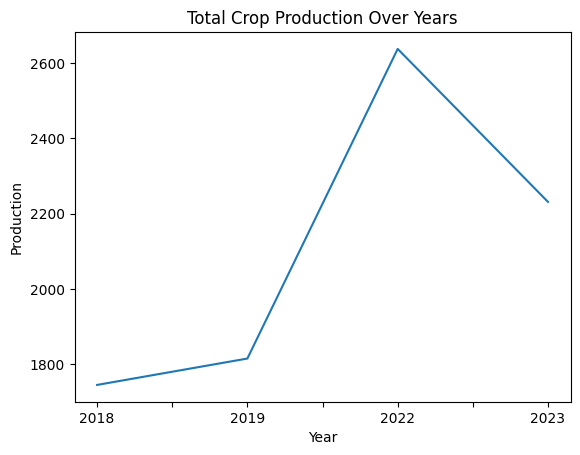

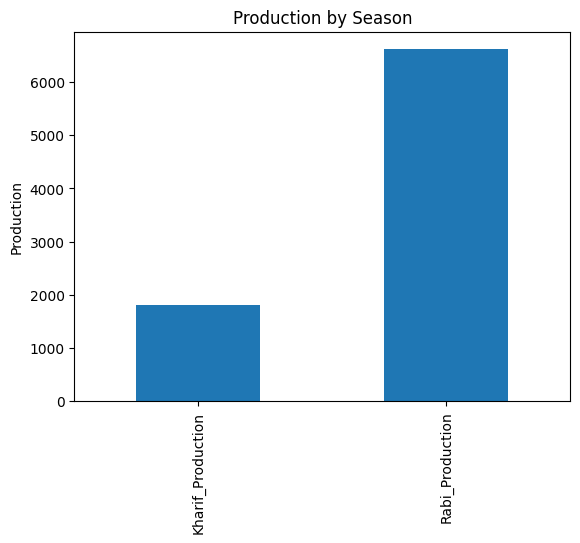

In [27]:
# 1. Year-wise trend
year_trend = df_clean.groupby('Year')['Total_Production'].sum()

year_trend.plot(kind='line')
plt.title("Total Crop Production Over Years")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()

# 2. Season-wise production
season = df_clean[['Kharif_Production', 'Rabi_Production']].sum()

season.plot(kind='bar')
plt.title("Production by Season")
plt.ylabel("Production")
plt.show()